In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

NB_DIR = Path().resolve()
sys.path.insert(0, str(NB_DIR))
from utils import load, DATA_DIR

MODELS_DIR = DATA_DIR / "models"

In [2]:
with open(MODELS_DIR / "rf_classifier.pkl", "rb") as f:
    clf, FEATURE_COLS = pickle.load(f)

test_preds = load("test_predictions")
print(f"Test predictions: {len(test_preds):,} rows")

Test predictions: 45 rows


## 1 · Feature Importance

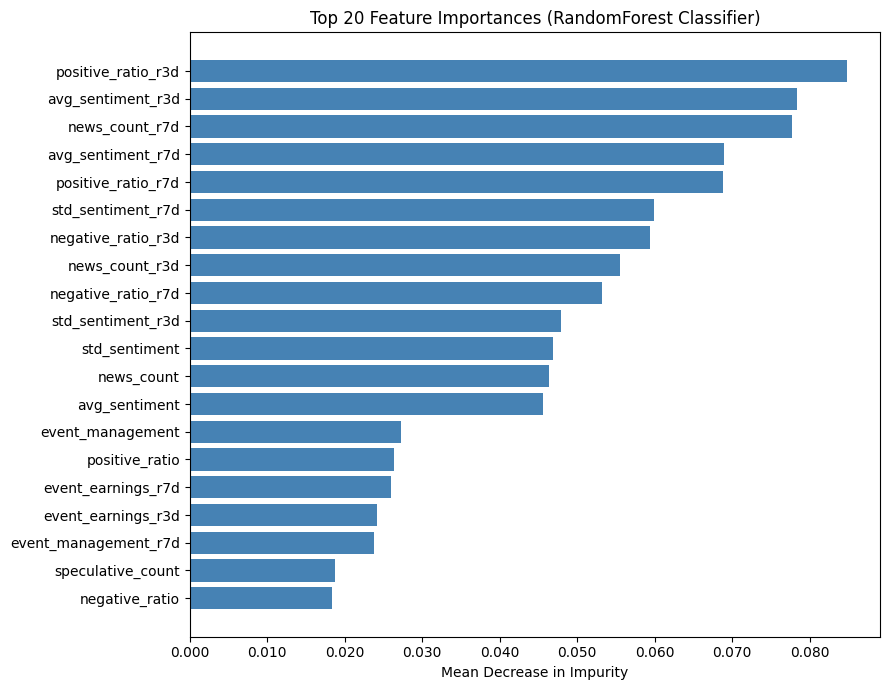

In [3]:
importances = (
    pd.Series(clf.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(importances.index, importances.values, color="steelblue")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Top 20 Feature Importances (RandomForest Classifier)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
plt.tight_layout()
plt.savefig(DATA_DIR / "feature_importance.png", dpi=150)
plt.show()

## 2 · Strategy backtest

**Rule:** Hold the stock on day `d+1` if `pred_direction == 1`, stay cash otherwise.

In [4]:
def run_backtest(preds: pd.DataFrame) -> pd.DataFrame:
    df = preds.sort_values("date").copy()
    # Strategy return: next_day_return if predicted up, else 0
    df["strategy_return"] = df["next_day_return"] * df["pred_direction"]
    df["bh_return"]       = df["next_day_return"]

    # Aggregate across all tickers per day (equal-weight portfolio)
    daily = df.groupby("date").agg(
        strategy=("strategy_return", "mean"),
        bh      =("bh_return",       "mean"),
        n_pos   =("pred_direction",  "sum"),
        n_total =("pred_direction",  "count"),
    )
    daily["cum_strategy"] = (1 + daily["strategy"]).cumprod()
    daily["cum_bh"]       = (1 + daily["bh"]).cumprod()
    return daily


daily = run_backtest(test_preds)
print(f"Backtest period: {daily.index.min().date()} → {daily.index.max().date()}")
print(f"Avg positions per day: {daily['n_pos'].mean():.1f} / {daily['n_total'].mean():.1f} tickers")

Backtest period: 2026-04-23 → 2026-05-12
Avg positions per day: 13.3 / 15.0 tickers


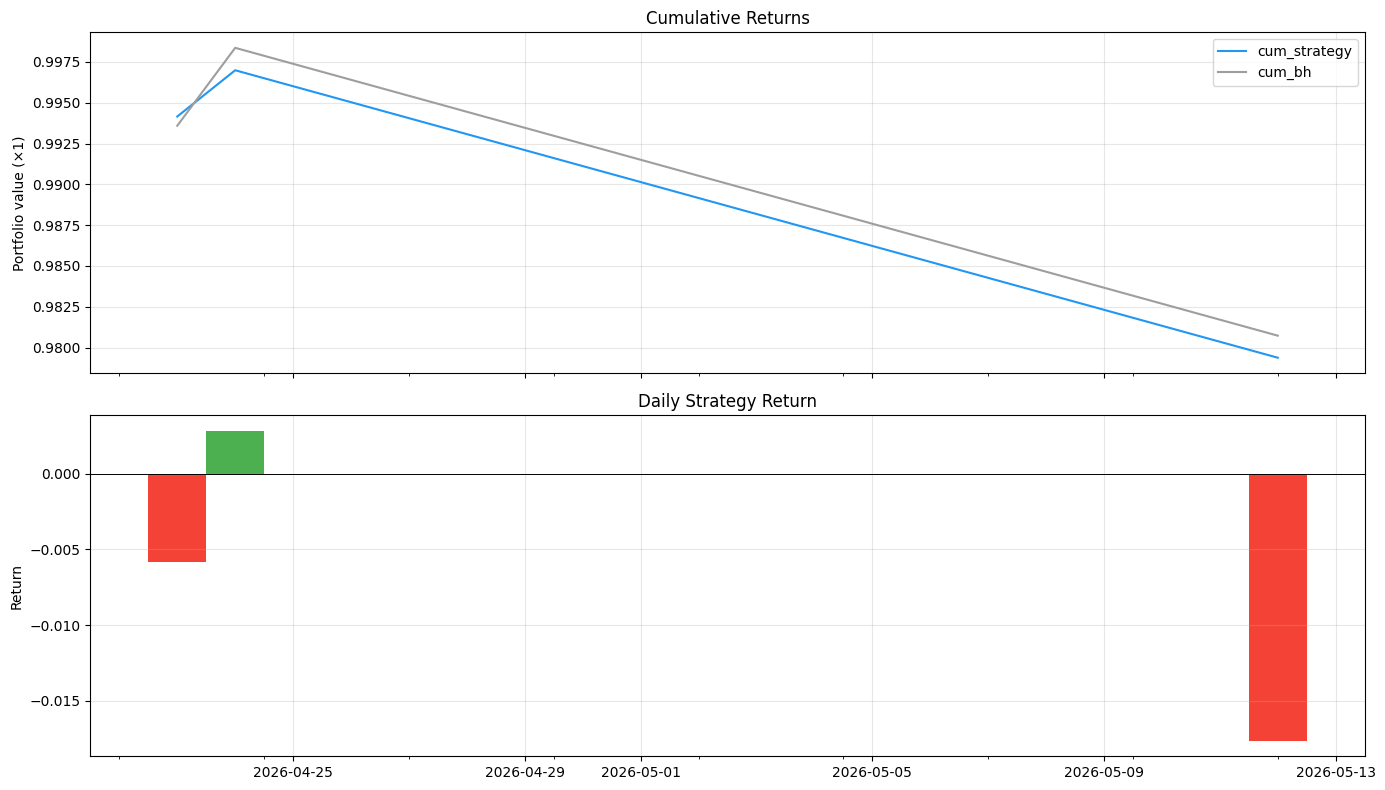

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

daily[["cum_strategy", "cum_bh"]].plot(
    ax=axes[0],
    color=["#2196F3", "#9E9E9E"],
    label=["Signal strategy", "Buy & Hold"],
)
axes[0].set_title("Cumulative Returns")
axes[0].set_ylabel("Portfolio value (×1)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Daily strategy return (bar)
colors = ["#4CAF50" if r > 0 else "#F44336" for r in daily["strategy"]]
axes[1].bar(daily.index, daily["strategy"], color=colors, width=1)
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].set_title("Daily Strategy Return")
axes[1].set_ylabel("Return")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "backtest.png", dpi=150)
plt.show()

## 3 · Performance metrics

In [6]:
def sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    if returns.std() == 0:
        return 0.0
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)


def max_drawdown(cum: pd.Series) -> float:
    roll_max = cum.cummax()
    return ((cum - roll_max) / roll_max).min()


def total_return(x):   return (1 + x).prod() - 1
def annualised_vol(x): return x.std() * np.sqrt(252)
def win_rate(x):       return (x > 0).mean()

metrics = pd.DataFrame({
    "Strategy":   daily["strategy"],
    "Buy & Hold": daily["bh"],
}).agg([total_return, annualised_vol, win_rate]).T

metrics["sharpe"]       = [
    sharpe(daily["strategy"]),
    sharpe(daily["bh"]),
]
metrics["max_drawdown"] = [
    max_drawdown(daily["cum_strategy"]),
    max_drawdown(daily["cum_bh"]),
]

metrics[["total_return", "annualised_vol", "sharpe", "max_drawdown", "win_rate"]].style.format(
    {
        "total_return":   "{:.2%}",
        "annualised_vol": "{:.2%}",
        "sharpe":         "{:.2f}",
        "max_drawdown":   "{:.2%}",
        "win_rate":       "{:.2%}",
    }
)

,total_return,annualised_vol,sharpe,max_drawdown,win_rate
Strategy,-2.06%,16.35%,-10.62,-1.77%,33.33%
Buy & Hold,-1.93%,17.83%,-9.08,-1.77%,33.33%


## 4 · Per-ticker signal quality

In [7]:
per_ticker = (
    test_preds
    .assign(strategy_return=lambda d: d["next_day_return"] * d["pred_direction"])
    .groupby("ticker")
    .apply(lambda g: pd.Series({
        "n":              len(g),
        "pred_up_rate":   g["pred_direction"].mean(),
        "actual_up_rate": g["direction"].mean(),
        "accuracy":       (g["pred_direction"] == g["direction"]).mean(),
        "total_return":   (1 + g["strategy_return"]).prod() - 1,
    }), include_groups=False)
    .sort_values("accuracy", ascending=False)
)

print(per_ticker.head(15).to_string())

          n  pred_up_rate  actual_up_rate  accuracy  total_return
ticker                                                           
AKT     1.0           0.0             0.0       1.0      0.000000
ATW     1.0           1.0             1.0       1.0      0.004064
AFM     1.0           0.0             0.0       1.0      0.000000
REB     2.0           1.0             1.0       1.0      0.070408
LBV     1.0           0.0             0.0       1.0      0.000000
TMA     1.0           0.0             0.0       1.0      0.000000
COL     2.0           1.0             0.5       0.5     -0.005941
ATL     2.0           1.0             0.5       0.5      0.002278
ATH     2.0           1.0             0.5       0.5     -0.001600
RIS     2.0           1.0             0.5       0.5      0.000000
SMI     2.0           1.0             0.5       0.5     -0.011222
SNA     2.0           1.0             0.5       0.5     -0.006811
IMO     2.0           1.0             0.5       0.5     -0.002198
LES     2.